# Bài tập 2:

## 1.In Biểu diễn nhị phân của số nguyên.

In [2]:
import time
import matplotlib.pyplot as plt

In [8]:
# using recursion print out binary of a interger
def print_binary_recursion(n):
  if n > 1:
    print_binary_recursion(n//2)
  print(n%2, end = "")

In [4]:
def print_binary_non_recursion(n):
  binary_string = ""
  while n > 0:
    binary_string = str(n%2) + binary_string
    n //= 2
  print(binary_string)

In [5]:
def measure_time(func, input_size):
  start_time = time.time()
  func(input_size)
  end_time = time.time()
  return end_time - start_time

10101010
11001001100100
11111010001111101000
1001110001000010011100010000
1100001101010000011000011010100000


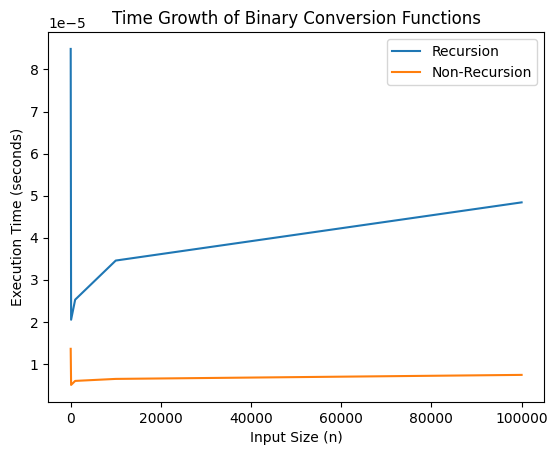

In [9]:
input_sizes = [10, 100, 1000, 10000, 100000]
execution_times_recursion = []
execution_times_non_recursion = []

for size in input_sizes:
  time_recursion = measure_time(print_binary_recursion, size)
  execution_times_recursion.append(time_recursion)

  time_non_recursion = measure_time(print_binary_non_recursion, size)
  execution_times_non_recursion.append(time_non_recursion)

plt.plot(input_sizes, execution_times_recursion, label="Recursion")
plt.plot(input_sizes, execution_times_non_recursion, label="Non-Recursion")
plt.xlabel("Input Size (n)")
plt.ylabel("Execution Time (seconds)")
plt.title("Time Growth of Binary Conversion Functions")
plt.legend()
plt.show()

## 2.Phân tích số nguyên thành tích các thừa số nguyên tố.

In [10]:
# Using recursion
def prime_factorization_recursion(n, factor = 2):
  if n <= 1:
    return []
  elif n % factor == 0:
    return [factor] + prime_factorization_recursion(n//factor, factor)
  else:
    return prime_factorization_recursion(n, factor + 1)

In [11]:
# Not using recursion
def prime_factorization_non_recursion(n):
  factors = []
  factor = 2
  while n > 1:
    while n % factor == 0:
      factors.append(factor)
      n //= factor
    factor += 1
  return factors

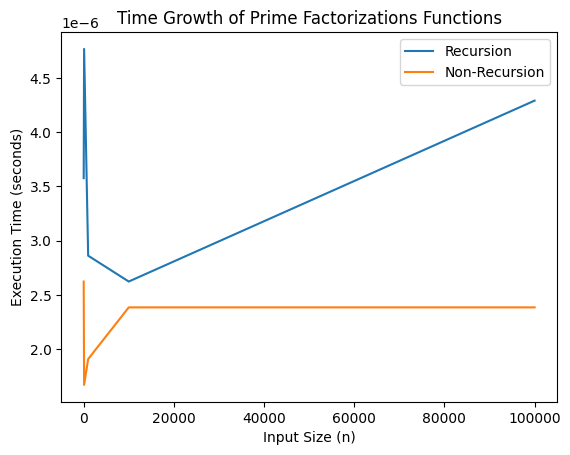

In [13]:
input_sizes = [10, 100, 1000, 10000, 100000]
execution_times_recursion = []
execution_times_non_recursion = []

for size in input_sizes:
  time_recursion = measure_time(prime_factorization_recursion, size)
  execution_times_recursion.append(time_recursion)

  time_non_recursion = measure_time(prime_factorization_non_recursion, size)
  execution_times_non_recursion.append(time_non_recursion)

plt.plot(input_sizes, execution_times_recursion, label="Recursion")
plt.plot(input_sizes, execution_times_non_recursion, label="Non-Recursion")
plt.xlabel("Input Size (n)")
plt.ylabel("Execution Time (seconds)")
plt.title("Time Growth of Prime Factorizations Functions")
plt.legend()
plt.show()

## 3. Bài toán Tháp Hà Nội.

In [19]:
def move_1_disk(A, B):
    # print(f"Chuyển đĩa từ {A} đến {B}")
    pass

In [15]:
def hanoi_non_recursive(n, source, target, auxiliary):
    stack = []
    stack.append((n, source, target, auxiliary, 1))
    moves = []

    while stack:
        n, A, B, C, m = stack.pop()

        if n > 1:
            if m == 1:
                stack.append((n, A, B, C, 2))
                n -= 1
                A, C = C, A
                stack.append((n, A, B, C, 1))
            elif m == 2:
                move_1_disk(A, B)
                n -= 1
                A, C = C, A
                stack.append((n, A, B, C, 1))
        else:
            move_1_disk(A, B)

    return moves

In [16]:
def hanoi_recursive(n, A, B, C):
    if n == 1:
        move_1_disk(A, B)
    else:
        hanoi_recursive(n - 1, A, C, B)
        move_1_disk(A, B)
        hanoi_recursive(n - 1, C, B, A)

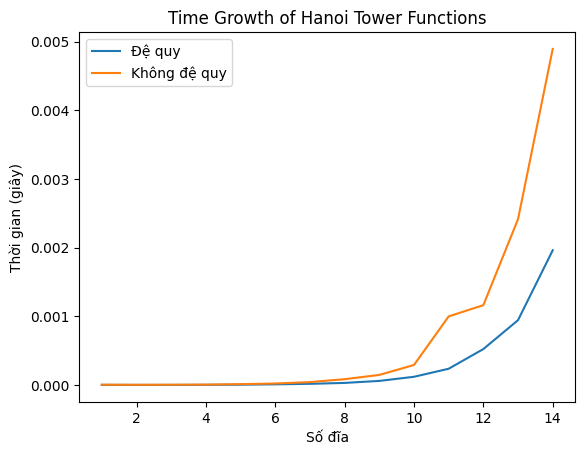

[]

In [21]:
sizes = list(range(1, 15))
recursive_times = []
non_recursive_times = []

for n in sizes:
    start = time.time()
    hanoi_recursive(n, 'A', 'C', 'B')
    recursive_times.append(time.time() - start)

    start = time.time()
    hanoi_non_recursive(n, 'A', 'C', 'B')
    non_recursive_times.append(time.time() - start)

plt.plot(sizes, recursive_times, label='Đệ quy')
plt.plot(sizes, non_recursive_times, label='Không đệ quy')
plt.xlabel('Số đĩa')
plt.ylabel('Thời gian (giây)')
plt.legend()
plt.title('Time Growth of Hanoi Tower Functions')
plt.show()

# Sử dụng hàm
n = 3  # Số đĩa
hanoi_non_recursive(n, 'A', 'C', 'B')

#Bài tập 3:

  **Bài toán chia thưởng:** Có m phần thưởng được thưởng cho n học sinh giỏi có xếp hạng theo thứ tự từ 1 đến n. Hỏi có bao nhiêu cách chia các phần thưởng thoả mãn các điều kiện sau:


*   Học sinh giỏi hơn có số phần thưởng không ít hơn bạn kém hơn.
*   m phần thưởng phải chia hết cho các học sinh.





**Phân tích bài toán:**

Bài toán yêu cầu tìm số cách chia `m` phần thưởng cho `n` học sinh giỏi sao cho học sinh giỏi hơn có số phần thưởng không ít hơn học sinh kém hơn và tất cả phần thưởng phải được chia hết. Đây là một bài toán tổ hợp có thể giải quyết bằng kỹ thuật đệ quy.

**Xây dựng thuật toán:**

Ta có thể sử dụng một hàm đệ quy `count_ways(n, m, current_student, rewards_so_far)` để tính toán số cách chia thưởng. Các tham số của hàm:

- `n`: Tổng số học sinh giỏi.
- `m`: Tổng số phần thưởng.
- `current_student`: Học sinh hiện tại đang được xem xét (từ 1 đến n).
- `rewards_so_far`: Số phần thưởng đã chia cho các học sinh trước đó.

Hàm đệ quy hoạt động như sau:

1. **Điều kiện dừng:**
    - Nếu `current_student` lớn hơn `n` (đã xem xét tất cả học sinh):
        - Nếu `rewards_so_far` bằng `m` (tất cả phần thưởng đã được chia):
            - Trả về 1 (tìm thấy một cách chia hợp lệ).
        - Ngược lại:
            - Trả về 0 (cách chia không hợp lệ).
2. **Lặp qua số phần thưởng có thể chia cho học sinh hiện tại:**
    - Bắt đầu từ số phần thưởng của học sinh trước đó (hoặc 0 nếu là học sinh đầu tiên) đến `m - rewards_so_far` (số phần thưởng còn lại).
    - Gọi đệ quy `count_ways` với `current_student + 1` và `rewards_so_far + current_rewards` (cập nhật số phần thưởng đã chia).
    - Cộng kết quả trả về từ các lời gọi đệ quy vào tổng số cách.
3. **Trả về tổng số cách.**

**Chứng minh tính đúng:**

Thuật toán này duyệt qua tất cả các cách chia thưởng có thể có, đảm bảo rằng học sinh giỏi hơn luôn có số phần thưởng không ít hơn học sinh kém hơn. Điều kiện dừng đảm bảo rằng tất cả phần thưởng được chia hết và chỉ các cách chia hợp lệ mới được tính.

**Đánh giá độ phức tạp:**

Độ phức tạp của thuật toán là O(m^n), vì trong trường hợp xấu nhất, mỗi học sinh có thể nhận được từ 0 đến m phần thưởng, và có n học sinh.

**Chương trình minh hoạ:**
```python
def count_ways(n, m, current_student=1, rewards_so_far=0):
    if current_student > n:
        return 1 if rewards_so_far == m else 0

    ways = 0
    min_rewards = 0 if current_student == 1 else rewards_so_far // (current_student -1) #Phần thưởng tối thiểu cho học sinh hiện tại
    
    for current_rewards in range(min_rewards, m - rewards_so_far + 1):
        ways += count_ways(n, m, current_student + 1, rewards_so_far + current_rewards)

    return ways
```
